# 2D toric code — electric FM order parameter: raw view + 3-model fits

Analysis of `O_FM(h_z)` from `results/tc2d_electric/fm2d_L{L}_electric.json`
(electric σ^z string, hx=0). Structure:

1. **Raw view (no fit)** — `O_FM(h_z)` and its finite-size derivative `dO_FM/dh_z`,
   both overlaid across L, to see the derivative peak and how it drifts with L.
2. **Raw-data dict** — `data[L]` and `raw[L]` for direct (L, h_z) → (O_FM, dO_FM) access.
3. **Three fits × {with, without error bars}**, optionally on an h_z **window**:
   - **tanh** (4p): `A + B·tanh((h−h_c)/w)` — h_c is the fit parameter (symmetric).
   - **Richards** (5p): `A + (K−A)/[1+e^{−(h−h₀)/w}]^ν` — asymmetric; the inflection is
     **`h_c = h₀ + w·ln ν`**, *not* h₀.
   - **erf** (4p): `A + B·erf((h−h_c)/(√2·w))` — symmetric, Gaussian (faster) tails.
   The **without-errors** fit is the honest baseline: MCMC `error_of_mean` underestimates
   the true uncertainty (autocorrelated samples; O_FM is a ratio of two expectations),
   so weighting by it over-trusts noisy points.
4. **(optional) FSS** — `h_c(L)` vs `1/L → h_c(∞)`, per variant, vs the analytic 0.328.


In [9]:
import glob, json, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erf as _erf

def _resolve(rel):                              # find the dir regardless of kernel CWD
    d = os.path.abspath(".")
    for _ in range(5):
        if os.path.isdir(os.path.join(d, rel)): return os.path.join(d, rel)
        d = os.path.dirname(d)
    return rel
CURVE_DIR    = _resolve("results/tc2d_electric")   # pulled fm2d_L*_electric.json
H_C_ANALYTIC = 0.328                            # 3D-Ising / (2+1)D TFIM critical field
FIT_WINDOW   = None    # None=full range | (lo,hi)=global | {L:(lo,hi)}=per-L override
EXCLUDE_L    = {12}   # sizes dropped from ALL cells (viz/fits/FSS); set() keeps all

def _window_for(L):
    if isinstance(FIT_WINDOW, dict):  return FIT_WINDOW.get(L)
    return FIT_WINDOW

def load_electric(curve_dir=CURVE_DIR):
    """{L: {hz,O,Oe,dO}} sorted by L; dO = finite-size derivative dO_FM/dhz."""
    data = {}
    for p in sorted(glob.glob(os.path.join(curve_dir, "fm2d_L*.json"))):
        r = json.load(open(p))
        if int(r["L"]) in EXCLUDE_L: continue    # honor EXCLUDE_L
        hz = np.asarray(r["field"], float); O = np.asarray(r["O"], float)
        idx = np.argsort(hz); hz, O = hz[idx], O[idx]
        Oe = np.asarray(r["Oe"], float)[idx]
        data[int(r["L"])] = {"hz": hz, "O": O, "Oe": Oe, "dO": np.gradient(O, hz)}
    return dict(sorted(data.items()))

data = load_electric()
print("loaded L =", list(data) or "NONE — pull fm2d_L*_electric.json into", CURVE_DIR)
for L, d in data.items():
    print(f"  L={L}: {len(d['hz'])} hz points in [{d['hz'].min():.3f}, {d['hz'].max():.3f}]")


loaded L = [6, 8, 10, 12] /Users/sanzhar123/Desktop/Approximate-Symmetries-TC-main/results/tc2d_electric
  L=6: 25 hz points in [0.200, 0.550]
  L=8: 25 hz points in [0.200, 0.550]
  L=10: 25 hz points in [0.200, 0.550]
  L=12: 25 hz points in [0.200, 0.550]


## 1. Raw view — no fit

Left: `O_FM(h_z)` per L (error bars are the MCMC `Oe`, shown but not trusted).
Right: finite-difference `dO_FM/dh_z`; the dashed vertical is each L's derivative-peak
`h_z`. Watch how the peak drifts with L toward the thermodynamic value.

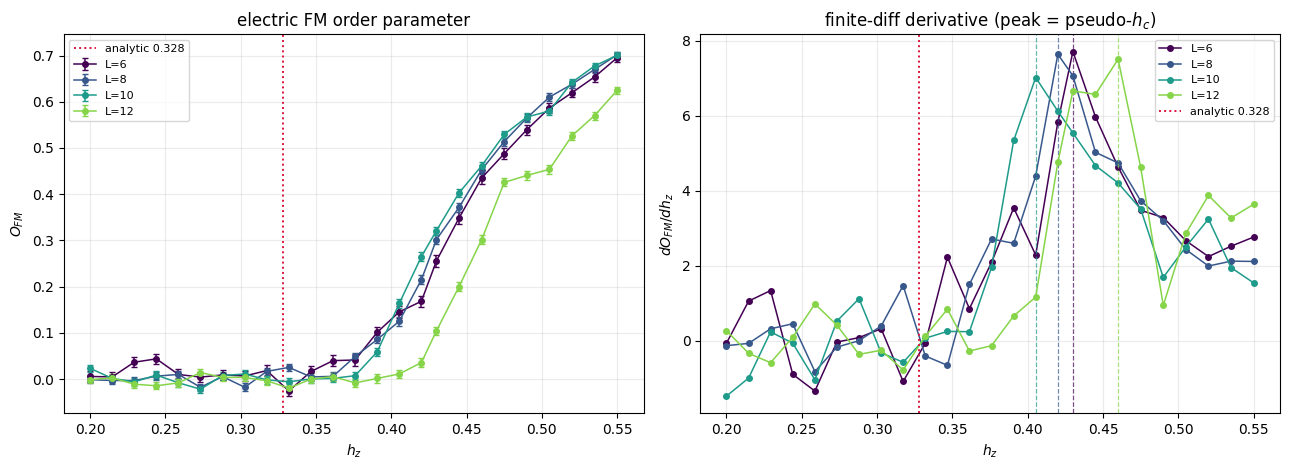

derivative-peak h_z by L: {6: 0.43, 8: 0.42, 10: 0.4053, 12: 0.46}


In [10]:
fig, (axO, axD) = plt.subplots(1, 2, figsize=(13, 4.8))
colors = plt.cm.viridis(np.linspace(0, 0.82, len(data)))
peak = {}
for (L, d), c in zip(data.items(), colors):
    axO.errorbar(d["hz"], d["O"], yerr=d["Oe"], fmt="o-", ms=4, lw=1.1, capsize=2,
                 color=c, label=f"L={L}")
    axD.plot(d["hz"], d["dO"], "o-", ms=4, lw=1.1, color=c, label=f"L={L}")
    hp = float(d["hz"][np.argmax(np.abs(d["dO"]))]); peak[L] = hp
    axD.axvline(hp, ls="--", lw=0.9, color=c, alpha=0.7)
for ax in (axO, axD):
    ax.axvline(H_C_ANALYTIC, color="crimson", lw=1.4, ls=":", label=f"analytic {H_C_ANALYTIC}")
    ax.grid(alpha=0.25); ax.legend(fontsize=8)
axO.set(xlabel="$h_z$", ylabel="$O_{FM}$", title="electric FM order parameter")
axD.set(xlabel="$h_z$", ylabel="$dO_{FM}/dh_z$", title="finite-diff derivative (peak = pseudo-$h_c$)")
fig.tight_layout(); plt.show()
print("derivative-peak h_z by L:", {L: round(v, 4) for L, v in peak.items()})


## 2. Raw-data dict

`data[L]` holds arrays (`hz`, `O`, `Oe`, `dO`). `raw[L]["by_hz"][hz]` gives the
`(O_FM, dO_FM)` pair for a specific field value.

In [11]:
raw = {}
for L, d in data.items():
    raw[L] = {"hz": d["hz"], "O_FM": d["O"], "dO_FM": d["dO"],
              "by_hz": {round(float(h), 4): (float(o), float(g))
                        for h, o, g in zip(d["hz"], d["O"], d["dO"])}}

# example lookups
for L in raw:
    h0 = raw[L]["hz"][len(raw[L]["hz"]) // 2]
    o, g = raw[L]["by_hz"][round(float(h0), 4)]
    print(f"L={L}: at hz={h0:.4f}  O_FM={o:.4f}  dO_FM/dhz={g:.3f}")
# `raw` and `data` are now in scope for ad-hoc inspection.


L=6: at hz=0.3760  O_FM=0.0415  dO_FM/dhz=2.093
L=8: at hz=0.3760  O_FM=0.0491  dO_FM/dhz=2.715
L=10: at hz=0.3760  O_FM=0.0076  dO_FM/dhz=1.960
L=12: at hz=0.3760  O_FM=-0.0081  dO_FM/dhz=-0.132


## 3. Fit models + driver

Each model returns `h_c` (the inflection — for Richards, `h₀ + w·ln ν`). `fit_one`
takes `use_errors` (weight by `Oe` with `absolute_sigma=True`) and an optional
`window=(lo,hi)`.

In [12]:
def f_tanh(h, A, B, hc, w):      return A + B * np.tanh((h - hc) / w)
def f_erf (h, A, B, hc, w):      return A + B * _erf((h - hc) / (np.sqrt(2.0) * w))
def f_richards(h, A, K, h0, w, nu):
    return A + (K - A) / (1.0 + np.exp(-(h - h0) / w)) ** nu

MODELS = {"tanh": f_tanh, "erf": f_erf, "richards": f_richards}
NPAR   = {"tanh": 4, "erf": 4, "richards": 5}
PARAMS = {"tanh": ["A", "B", "h_c", "w"], "erf": ["A", "B", "h_c", "w"],
          "richards": ["A", "K", "h0", "w", "nu"]}

def _p0_bounds(name, h, O):
    lo, hi = float(h.min()), float(h.max()); rng = (hi - lo) or 1.0
    fd_peak = float(h[np.argmax(np.abs(np.gradient(O, h)))])
    A0, B0, w0 = float(np.mean(O)), float((O[-1] - O[0]) / 2), max(0.05 * rng, 1e-3)
    pad = 0.5 * rng
    if name in ("tanh", "erf"):
        return [A0, B0, fd_peak, w0], ([-np.inf, -np.inf, lo - pad, 1e-6],
                                       [np.inf, np.inf, hi + pad, np.inf])
    return [float(O[0]), float(O[-1]), fd_peak, w0, 1.0], (
        [-np.inf, -np.inf, lo - pad, 1e-6, 1e-3], [np.inf, np.inf, hi + pad, np.inf, 1e3])

def fit_one(name, h, O, Oe, use_errors, window=None):
    """Fit one model. Returns dict(popt, perr, hc, hc_err, h, O) or None on failure."""
    h, O, Oe = np.asarray(h, float), np.asarray(O, float), np.asarray(Oe, float)
    if window is not None:
        m = (h >= window[0]) & (h <= window[1]); h, O, Oe = h[m], O[m], Oe[m]
    if len(h) < NPAR[name] + 1:
        return None
    p0, bounds = _p0_bounds(name, h, O)
    kw = dict(sigma=Oe, absolute_sigma=True) if (use_errors and np.all(Oe > 0)) else {}
    try:
        popt, pcov = curve_fit(MODELS[name], h, O, p0=p0, bounds=bounds, maxfev=40000, **kw)
    except Exception as exc:
        print(f"  [fit] {name} (errs={use_errors}) failed: {exc}"); return None
    perr = np.sqrt(np.abs(np.diag(pcov)))
    if name == "richards":
        A, K, h0, w, nu = popt
        hc = h0 + w * np.log(nu)                      # inflection, NOT h0
        hc_err = float(np.sqrt(perr[2]**2 + (np.log(nu)*perr[3])**2 + (w/nu*perr[4])**2))
    else:
        hc, hc_err = float(popt[2]), float(perr[2])
    return {"popt": popt, "perr": perr, "hc": float(hc), "hc_err": hc_err, "h": h, "O": O}


## 4. Run all fits — 3 models × {with, without errors}

`fits[(L, model, use_err)]`. The table lists `h_c ± err`; per model, one panel per L
overlays the data with both fits (solid = with errors, dashed = without).

  L model     errs         h_c     ± err   params
  6 tanh      True      0.4485    0.0015   A=0.349, B=0.342, h_c=0.449, w=0.0592
  6 tanh      False     0.4476    0.0026   A=0.346, B=0.339, h_c=0.448, w=0.0581
  6 richards  True      0.4373    0.1606   A=0.0125, K=0.752, h0=0.325, w=0.0484, nu=10.3
  6 richards  False     0.4379    0.1596   A=0.0124, K=0.742, h0=0.35, w=0.0462, nu=6.7
  6 erf       True      0.4483    0.0015   A=0.348, B=0.338, h_c=0.448, w=0.0493
  6 erf       False     0.4476    0.0025   A=0.345, B=0.335, h_c=0.448, w=0.0484
  8 tanh      True      0.4428    0.0010   A=0.345, B=0.351, h_c=0.443, w=0.0576
  8 tanh      False     0.4418    0.0018   A=0.342, B=0.348, h_c=0.442, w=0.0565
  8 richards  True      0.4288    9.0121   A=0.00207, K=0.748, h0=0.102, w=0.0473, nu=1e+03
  8 richards  False     0.4289    0.9048   A=0.00216, K=0.742, h0=0.234, w=0.0462, nu=68
  8 erf       True      0.4425    0.0010   A=0.343, B=0.345, h_c=0.443, w=0.0476
  8 erf       False     

/var/folders/qq/fj8fj1hj4q98rqt9p4pjwdn40000gn/T/ipykernel_30508/1696280690.py:4: RuntimeWarning: overflow encountered in power
  return A + (K - A) / (1.0 + np.exp(-(h - h0) / w)) ** nu


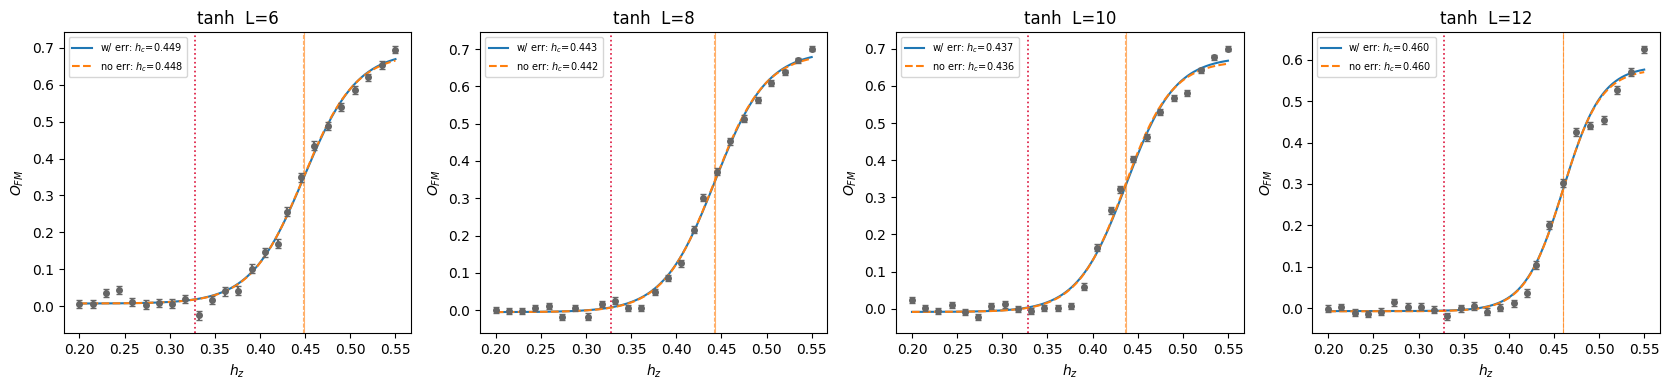

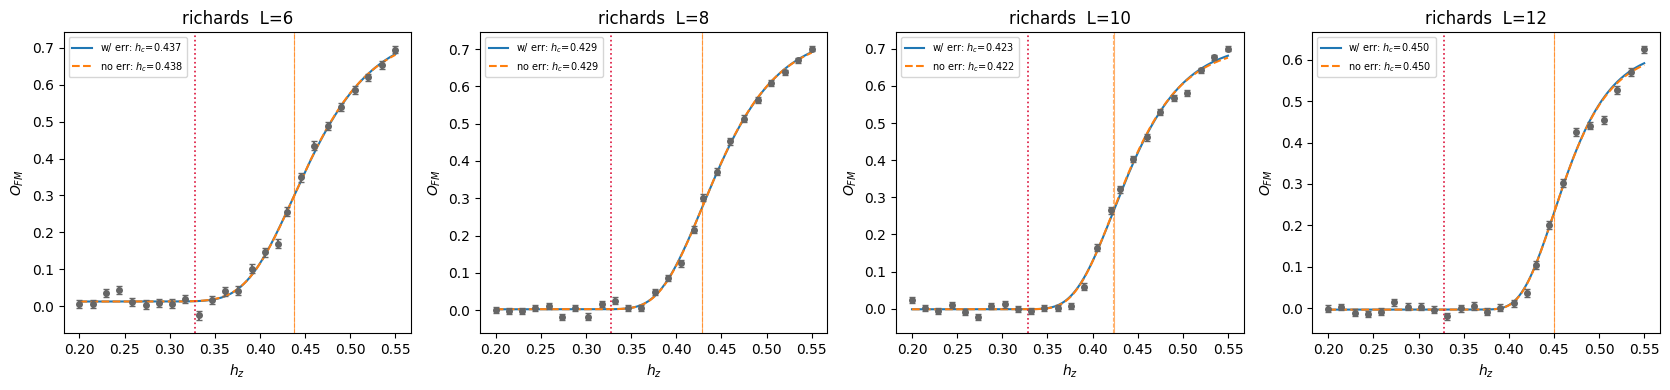

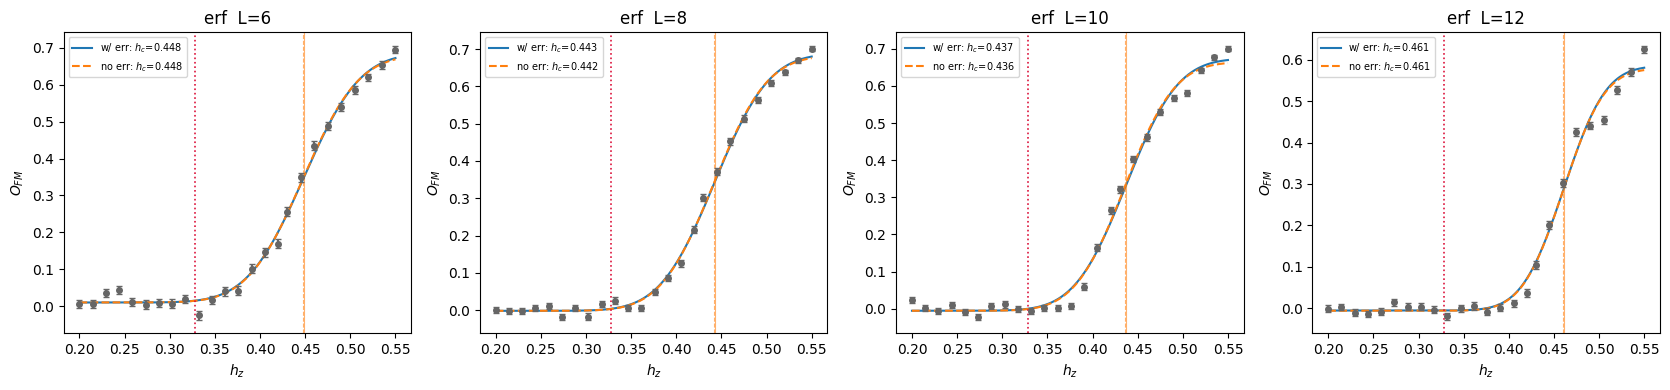

In [13]:
MODELS_ORDER = ["tanh", "richards", "erf"]
fits = {}
print(f"{'L':>3} {'model':9} {'errs':6} {'h_c':>9} {'± err':>9}   params")
for L, d in data.items():
    for name in MODELS_ORDER:
        for use_err in (True, False):
            fit = fit_one(name, d["hz"], d["O"], d["Oe"], use_err, window=_window_for(L))
            fits[(L, name, use_err)] = fit
            if fit is None:
                print(f"{L:>3} {name:9} {str(use_err):6} {'--':>9}"); continue
            pstr = ", ".join(f"{k}={v:.3g}" for k, v in zip(PARAMS[name], fit["popt"]))
            print(f"{L:>3} {name:9} {str(use_err):6} {fit['hc']:>9.4f} {fit['hc_err']:>9.4f}   {pstr}")

# overlay: one figure per model, a panel per L
for name in MODELS_ORDER:
    Ls = list(data); n = len(Ls)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4.0), squeeze=False)
    for ax, L in zip(axes[0], Ls):
        d = data[L]
        ax.errorbar(d["hz"], d["O"], yerr=d["Oe"], fmt="o", ms=4, color="0.4", capsize=2, zorder=3)
        for use_err, style in ((True, "-"), (False, "--")):
            fit = fits[(L, name, use_err)]
            if fit is None: continue
            hh = np.linspace(fit["h"].min(), fit["h"].max(), 400)
            ax.plot(hh, MODELS[name](hh, *fit["popt"]), style,
                    label=f"{'w/' if use_err else 'no'} err: $h_c$={fit['hc']:.3f}")
            ax.axvline(fit["hc"], ls=style, lw=0.8, color="C1", alpha=0.6)
        ax.axvline(H_C_ANALYTIC, color="crimson", lw=1.2, ls=":")
        w = _window_for(L)
        if w: ax.axvspan(w[0], w[1], color="gold", alpha=0.08)
        ax.set(xlabel="$h_z$", ylabel="$O_{FM}$", title=f"{name}  L={L}"); ax.legend(fontsize=7)
    fig.tight_layout(); plt.show()


## 5. (optional) Finite-size scaling → h_c(∞)

For each variant, fit `h_c(L) = h_c(∞) + a/L` and compare the intercept with the
analytic 0.328. Six variants (3 models × 2 error options) bracket both the
statistical and the model-shape systematics.

model     errs    h_c(inf)  dev@0.328   per-L h_c
tanh      True      0.4547    +0.1267   L6=0.4485 L8=0.4428 L10=0.4372 L12=0.4605
tanh      False     0.4536    +0.1256   L6=0.4476 L8=0.4418 L10=0.4356 L12=0.4599
richards  True      0.4419    +0.1139   L6=0.4373 L8=0.4288 L10=0.4233 L12=0.4499
richards  False     0.4401    +0.1121   L6=0.4379 L8=0.4289 L10=0.4224 L12=0.4495
erf       True      0.4558    +0.1278   L6=0.4483 L8=0.4425 L10=0.4374 L12=0.4610
erf       False     0.4548    +0.1268   L6=0.4476 L8=0.4417 L10=0.4359 L12=0.4605


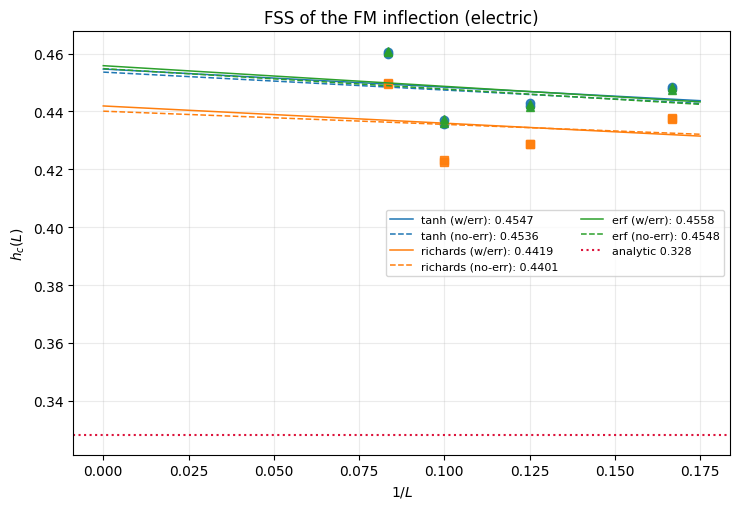

In [14]:
def fss_intercept(hc_by_L):
    Ls = np.array(sorted(hc_by_L), float); y = np.array([hc_by_L[L] for L in Ls])
    if len(Ls) < 2: return None
    a, b = np.polyfit(1.0 / Ls, y, 1)            # y = b + a/L ; b = h_c(inf)
    return {"Ls": Ls, "y": y, "slope": a, "hc_inf": float(b)}

fig, ax = plt.subplots(figsize=(7.5, 5.2))
sty = {"tanh": "o", "richards": "s", "erf": "^"}
print(f"{'model':9} {'errs':6} {'h_c(inf)':>9} {'dev@0.328':>10}   per-L h_c")
for name in MODELS_ORDER:
    for use_err in (True, False):
        hc_by_L = {L: fits[(L, name, use_err)]["hc"] for L in data
                   if fits[(L, name, use_err)] is not None}
        fs = fss_intercept(hc_by_L)
        if fs is None: continue
        lab = f"{name} ({'w/err' if use_err else 'no-err'})"
        col = {"tanh": "C0", "richards": "C1", "erf": "C2"}[name]
        ls = "-" if use_err else "--"
        ax.plot(1.0 / fs["Ls"], fs["y"], sty[name], color=col, alpha=0.9)
        xs = np.linspace(0, (1.0 / fs["Ls"]).max() * 1.05, 50)
        ax.plot(xs, fs["hc_inf"] + fs["slope"] * xs, ls, color=col, lw=1.1,
                label=f"{lab}: {fs['hc_inf']:.4f}")
        print(f"{name:9} {str(use_err):6} {fs['hc_inf']:>9.4f} {fs['hc_inf']-H_C_ANALYTIC:>+10.4f}   "
              + " ".join(f"L{int(L)}={hc_by_L[L]:.4f}" for L in sorted(hc_by_L)))
ax.axhline(H_C_ANALYTIC, color="crimson", lw=1.5, ls=":", label=f"analytic {H_C_ANALYTIC}")
ax.set(xlabel="$1/L$", ylabel="$h_c(L)$", title="FSS of the FM inflection (electric)")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.25); fig.tight_layout(); plt.show()


### Notes
- **With vs without errors**: large gaps between the solid/dashed `h_c` flag points
  where the MCMC error bars steer the fit — trust the **no-err** column when they diverge.
- **Model spread** at fixed L is a systematic-uncertainty estimate for `h_c(L)`.
- **Windowing**: set `FIT_WINDOW=(lo,hi)` (or `{L:(lo,hi)}`) in cell 2 and re-run from
  the fit cell to exclude plateau/boundary points — useful where the finite-L inflection
  crowds the high-`h_z` edge.
